## Classification models

### Models:

In [ ]:
dt_model = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=5,
    random_state=42
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

gbt_model = HistGradientBoostingClassifier(
    max_depth=6,
    learning_rate=0.05,
    max_iter=200,
    random_state=42
)


### Model Evaluation Function

In [ ]:
def evaluate(model, name):

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    macro = f1_score(y_test, pred, average="macro")

    print(name)
    print("Accuracy:", acc)
    print("Macro F1:", macro)

    print(classification_report(y_test, pred, target_names=le.classes_))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        pred,
        display_labels=le.classes_,
        xticks_rotation=90
    )

    plt.title(name)

    plt.show()


### Run Models

#### Note

In this step multiple classification models are trained using the prepared dataset.

The goal is to evaluate how well different machine learning approaches can predict a candidate’s party affiliation based on their responses to political questions.


Decision Tree
Accuracy: 0.7687861271676301
Macro F1: 0.7674176041300557
                                             precision    recall  f1-score   support

                               Alternativet       0.57      0.57      0.57        14
                       Danmarksdemokraterne       1.00      0.86      0.92         7
                           Dansk Folkeparti       0.77      1.00      0.87        10
                Det Konservative Folkeparti       0.78      0.35      0.48        20
                               Enhedslisten       0.94      1.00      0.97        15
Frie Grønne, Danmarks Nye Venstrefløjsparti       0.50      0.80      0.62         5
                        Kristendemokraterne       0.75      0.38      0.50         8
                           Liberal Alliance       0.76      0.93      0.84        14
                                Moderaterne       0.89      1.00      0.94         8
                             Nye Borgerlige       0.90      0.90      0.90   

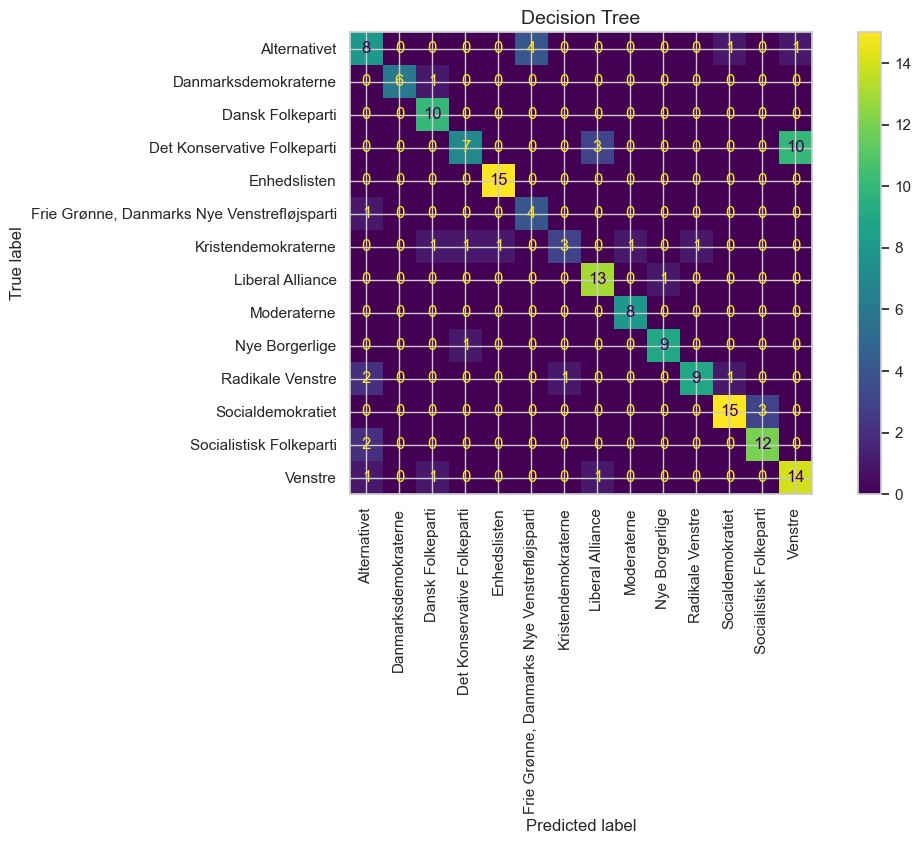

Random Forest
Accuracy: 0.9248554913294798
Macro F1: 0.9198271352006903
                                             precision    recall  f1-score   support

                               Alternativet       0.87      0.93      0.90        14
                       Danmarksdemokraterne       1.00      1.00      1.00         7
                           Dansk Folkeparti       0.91      1.00      0.95        10
                Det Konservative Folkeparti       0.94      0.85      0.89        20
                               Enhedslisten       1.00      1.00      1.00        15
Frie Grønne, Danmarks Nye Venstrefløjsparti       1.00      0.60      0.75         5
                        Kristendemokraterne       1.00      0.75      0.86         8
                           Liberal Alliance       0.82      1.00      0.90        14
                                Moderaterne       0.89      1.00      0.94         8
                             Nye Borgerlige       1.00      1.00      1.00   

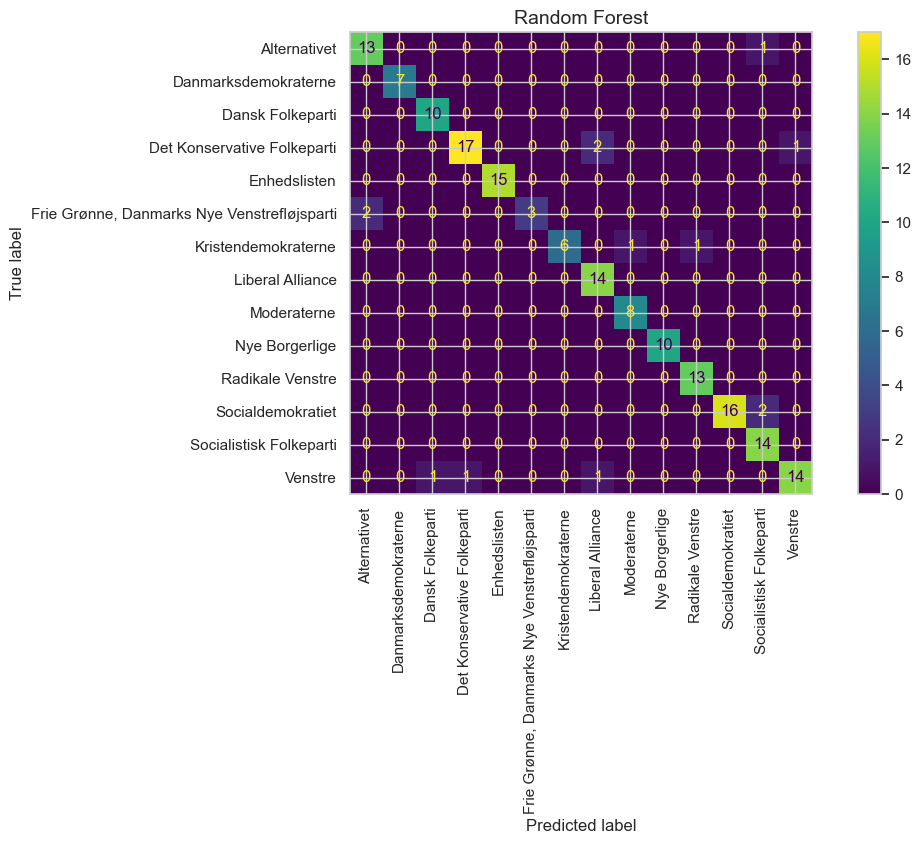

Gradient Boosted Tree
Accuracy: 0.9075144508670521
Macro F1: 0.8999557215040142
                                             precision    recall  f1-score   support

                               Alternativet       0.87      0.93      0.90        14
                       Danmarksdemokraterne       1.00      0.86      0.92         7
                           Dansk Folkeparti       0.91      1.00      0.95        10
                Det Konservative Folkeparti       0.95      0.90      0.92        20
                               Enhedslisten       1.00      0.93      0.97        15
Frie Grønne, Danmarks Nye Venstrefløjsparti       0.80      0.80      0.80         5
                        Kristendemokraterne       1.00      0.62      0.77         8
                           Liberal Alliance       0.88      1.00      0.93        14
                                Moderaterne       0.89      1.00      0.94         8
                             Nye Borgerlige       1.00      0.90     

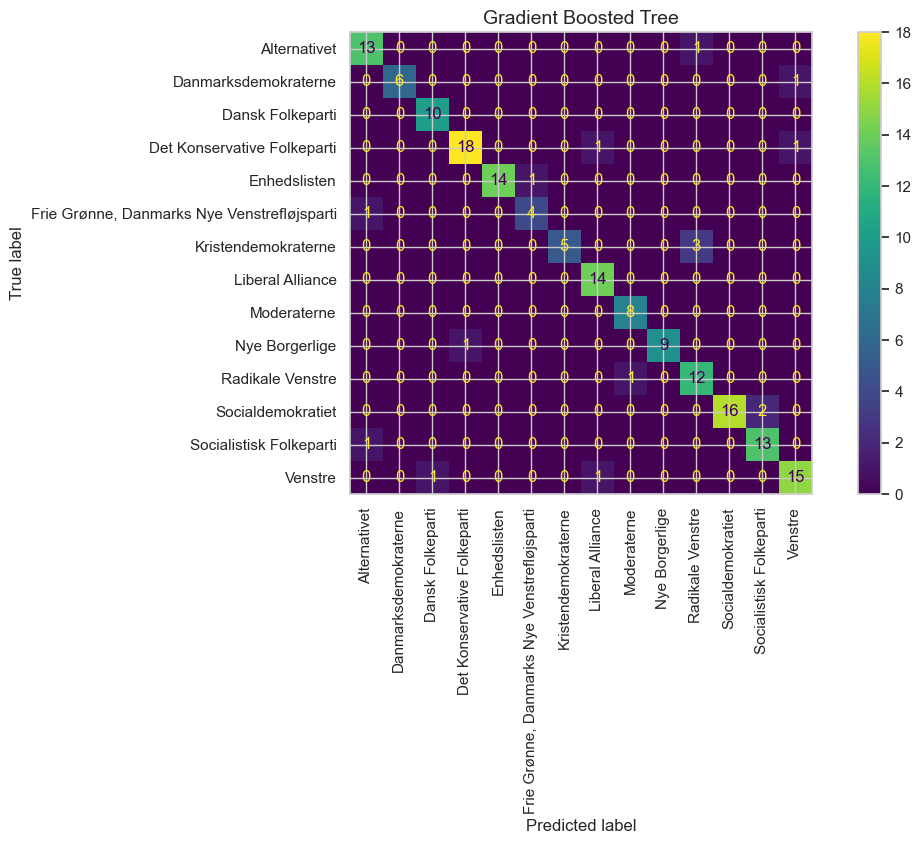

In [ ]:
evaluate(dt_model, "Decision Tree")

evaluate(rf_model, "Random Forest")

evaluate(gbt_model, "Gradient Boosted Tree")


## Cross-validation comparison


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Gradient Boosted Tree": gbt_model
}

results = []

for name, model in models.items():

    scores = cross_val_score(model, X, y_encoded, cv=cv)

    results.append({
        "model": name,
        "mean_accuracy": scores.mean(),
        "std": scores.std()
    })

cv_results = pd.DataFrame(results).sort_values("mean_accuracy", ascending=False)

display(cv_results)


,model,mean_accuracy,std
1,Random Forest,0.900470,0.029540
2,Gradient Boosted Tree,0.879688,0.032450
0,Decision Tree,0.704900,0.022375


### Interpretation

The cross-validation results show that ensemble models perform better than a single Decision Tree.

Random Forest achieves the highest mean accuracy (~0.90), followed by Gradient Boosted Trees (~0.88), while the single Decision Tree performs significantly worse (~0.70).

This suggests that combining multiple trees improves the model’s ability to capture patterns in the data and generalize better.

The relatively small standard deviations indicate that the model performance is stable across the cross-validation folds.
